In [1]:
import pandas as pd

nav = pd.read_csv(
    r"C:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\data\raw\02_nav_history.csv"
)

benchmark = pd.read_csv(
    r"C:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\data\raw\10_benchmark_indices.csv"
)

nav.head()
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [2]:
print(benchmark['index_name'].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [3]:
nifty50 = benchmark[
    benchmark['index_name'].str.contains(
        'Nifty 50',
        case=False,
        na=False
    )
]

In [4]:
fund = nav[
    nav['amfi_code'] == nav['amfi_code'].iloc[0]
].copy()

In [5]:
fund['date'] = pd.to_datetime(fund['date'])
nifty50['date'] = pd.to_datetime(nifty50['date'])

In [6]:
merged = pd.merge(
    fund,
    nifty50[['date','close_value']],
    on='date',
    how='inner'
)

In [9]:
print(merged.shape)
print(merged.head())

(0, 4)
Empty DataFrame
Columns: [amfi_code, date, nav, close_value]
Index: []


In [10]:
print(fund.head())
print(nifty50.head())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692
Empty DataFrame
Columns: [date, index_name, close_value]
Index: []


In [11]:
print(fund.columns)
print(nifty50.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['date', 'index_name', 'close_value'], dtype='object')


In [12]:
print("Fund rows:", len(fund))
print("Nifty rows:", len(nifty50))

Fund rows: 1150
Nifty rows: 0


In [13]:
print(benchmark['index_name'].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [15]:
print(benchmark['index_name'].unique())
print("Fund rows:", len(fund))
print("Nifty rows:", len(nifty50))
print("Merged rows:", len(merged))

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']
Fund rows: 1150
Nifty rows: 0
Merged rows: 0


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
nav = pd.read_csv(
    r"C:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\data\raw\02_nav_history.csv"
)

benchmark = pd.read_csv(
    r"C:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\data\raw\10_benchmark_indices.csv"
)

print(nav.head())
print(benchmark.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [18]:
fund = nav[
    nav['amfi_code'] == nav['amfi_code'].iloc[0]
].copy()

print("Fund rows:", len(fund))

Fund rows: 1150


In [19]:
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

print("NIFTY50 rows:", len(nifty50))

NIFTY50 rows: 1150


In [20]:
fund['date'] = pd.to_datetime(fund['date'])
nifty50['date'] = pd.to_datetime(nifty50['date'])

In [21]:
merged = pd.merge(
    fund,
    nifty50[['date', 'close_value']],
    on='date',
    how='inner'
)

print("Merged rows:", len(merged))
print(merged.head())

Merged rows: 1150
   amfi_code       date      nav  close_value
0     119551 2022-01-03  54.3856     17492.79
1     119551 2022-01-04  54.3474     17689.64
2     119551 2022-01-05  54.6869     17835.05
3     119551 2022-01-06  55.4550     17878.51
4     119551 2022-01-07  55.3692     17759.15


In [22]:
merged['fund_return'] = merged['nav'].pct_change()

merged['benchmark_return'] = (
    merged['close_value'].pct_change()
)

merged = merged.dropna()

print(merged.head())

   amfi_code       date      nav  close_value  fund_return  benchmark_return
1     119551 2022-01-04  54.3474     17689.64    -0.000702          0.011253
2     119551 2022-01-05  54.6869     17835.05     0.006247          0.008220
3     119551 2022-01-06  55.4550     17878.51     0.014045          0.002437
4     119551 2022-01-07  55.3692     17759.15    -0.001547         -0.006676
5     119551 2022-01-10  55.2835     18124.84    -0.001548          0.020592


In [23]:
beta = np.cov(
    merged['fund_return'],
    merged['benchmark_return']
)[0,1] / np.var(
    merged['benchmark_return']
)

alpha = (
    merged['fund_return'].mean()
    - beta *
    merged['benchmark_return'].mean()
)

print("Alpha =", alpha)
print("Beta =", beta)

Alpha = 0.0009214186250672951
Beta = -0.056093905387745155


In [24]:
tracking_error = (
    (
        merged['fund_return']
        - merged['benchmark_return']
    ).std()
) * np.sqrt(252)

print("Tracking Error =", tracking_error)

Tracking Error = 0.19311962181514383


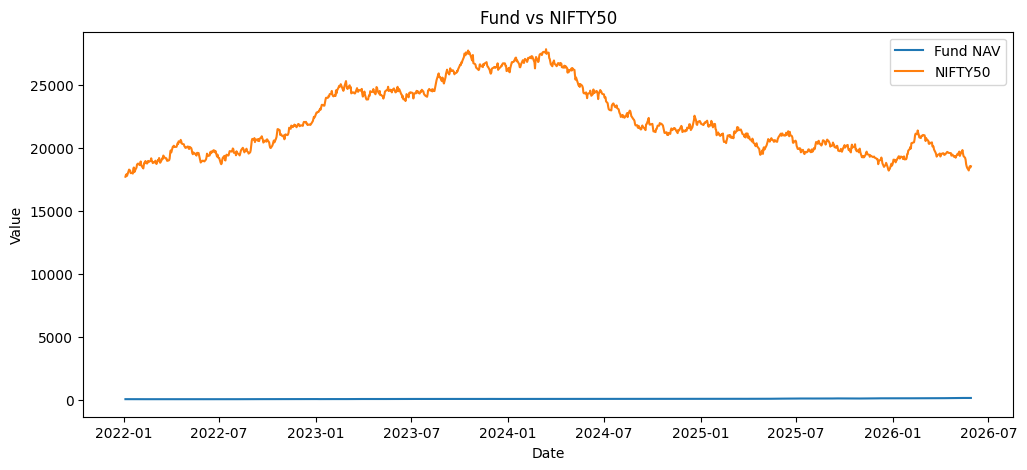

benchmark_comparison.csv saved successfully


In [25]:
plt.figure(figsize=(12,5))

plt.plot(
    merged['date'],
    merged['nav'],
    label='Fund NAV'
)

plt.plot(
    merged['date'],
    merged['close_value'],
    label='NIFTY50'
)

plt.title("Fund vs NIFTY50")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

result = pd.DataFrame({
    'Alpha':[alpha],
    'Beta':[beta],
    'Tracking_Error':[tracking_error]
})

result.to_csv(
    'benchmark_comparison.csv',
    index=False
)

print("benchmark_comparison.csv saved successfully")